# 3. Evaluacija i generisanje koda

Poredjeni su bazni Qwen2.5-Coder-1.5B (`base`), sopstveni adapter (`custom`) i PEFT adapter (`peft`).

## Postupak

Za svaki zadatak generisano je jedno resenje, greedy dekodiranjem, sa najvise 512 novih tokena. Sve varijante koristile su isti EvalPlus prompt, izdvajanje koda i testove. `pass@1` je ovde broj zadataka sa prolaznim resenjem podeljen ukupnim brojem zadataka.

HumanEval ima 164 zadatka, a korisceni MBPP skup 378. Varijante sa znakom `+` proveravaju ista resenja dodatnim testovima. Generisani kod je izvrsen u Docker kontejneru. Ovaj notebook ucitava agregirane rezultate iz JSON fajla.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
benchmark_data = json.loads((ROOT / "results/benchmark_summary.json").read_text(encoding="utf-8"))
results = pd.DataFrame(benchmark_data["results"])
benchmarks = ["HumanEval", "HumanEval+", "MBPP", "MBPP+"]
variants = ["base", "custom", "peft"]
table = results.pivot(index="benchmark", columns="variant", values="pass_at_1").loc[benchmarks, variants]
(table * 100).round(2).rename_axis("pass@1 (%)")

variant,base,custom,peft
pass@1 (%),,,
HumanEval,67.07,77.44,77.44
HumanEval+,60.37,70.73,70.12
MBPP,71.69,71.96,70.63
MBPP+,61.11,62.17,61.64


## Od odgovora do testiranja

`generate_solutions` sastavlja prompt, generise odgovor, uklanja tekst iza stop oznake i prosledjuje rezultat EvalPlus funkciji `sanitize`. Ona izdvaja trazenu funkciju i njene zavisnosti iz odgovora.

Sledeci odgovor je rucno napisan da prikaze obradu formata. `sanitize` izdvaja kod; njegovo izvrsavanje i ocenjivanje dolaze kasnije u Docker-u.

In [2]:
from evalplus.sanitize import sanitize

raw_response = """Funkcija sabira dva broja.

```python
def zbir(a, b):
    return a + b
```

Primer poziva: zbir(2, 3).
"""
solution = sanitize(raw_response, entrypoint="zbir")
print(solution)

def zbir(a, b):
    return a + b


Resenje se cuva uz `task_id` u JSONL fajlu. Evaluator zatim proverava originalne i dodatne testove za taj zadatak. Tek nakon toga se broje prolazi: za custom model na HumanEval+ to je $116 / 164 = 70{,}73\%$.

Na istim generisanim resenjima custom prolazi 127 originalnih HumanEval zadataka, ali samo 116 sa dodatnim testovima. Dodatni testovi su otkrili greske u resenjima 11 zadataka koja su prosla originalne testove.

## Rezultati

Intervali pouzdanosti su izracunati percentile bootstrap postupkom sa 10.000 ponovnih uzoraka zadataka i seed-om 42. Oni opisuju varijaciju preko zadataka; ne mere varijaciju izmedju ponovljenih treninga.

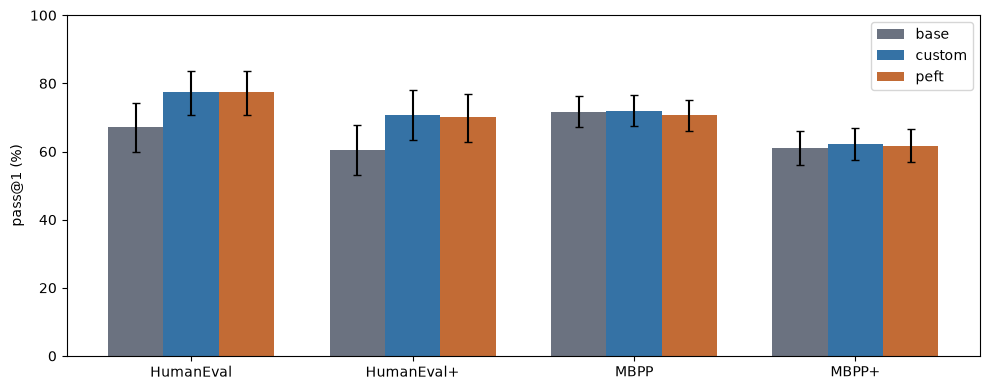

In [3]:
x = np.arange(len(benchmarks))
fig, ax = plt.subplots(figsize=(10, 4))
for i, (variant, color) in enumerate(zip(variants, ["#6b7280", "#3572a5", "#c26b35"])):
    rows = results[results["variant"] == variant].set_index("benchmark").loc[benchmarks]
    values = rows["pass_at_1"].to_numpy() * 100
    lower, upper = np.array(rows["ci95"].tolist()).T * 100
    ax.bar(x + (i - 1) * 0.25, values, 0.25, label=variant, color=color,
           yerr=[values - lower, upper - values], capsize=3)
ax.set(xticks=x, xticklabels=benchmarks, ylim=(0, 100), ylabel="pass@1 (%)")
ax.legend()
plt.tight_layout()
plt.show()

## Poredjenje sa baznim modelom

Dobitak oznacava zadatak na kome adapter prolazi, a bazni model pada. Gubitak oznacava obrnut slucaj. Prikazani su broj dobitaka i gubitaka, promena procenta prolaznosti i njen 95% bootstrap interval.

In [4]:
paired = pd.DataFrame(benchmark_data["paired_against_base"])
paired["promena (pp)"] = paired["delta"] * 100
paired["95% CI (pp)"] = paired["ci95"].map(lambda ci: f"[{100 * ci[0]:.2f}, {100 * ci[1]:.2f}]")
paired[["benchmark", "variant", "gains", "losses", "promena (pp)", "95% CI (pp)"]].round(4)

,benchmark,variant,gains,losses,promena (pp),95% CI (pp)
0,HumanEval+,custom,27,10,10.3659,"[3.05, 17.68]"
1,HumanEval+,peft,26,10,9.7561,"[2.44, 16.46]"
2,MBPP+,custom,25,21,1.0582,"[-2.65, 4.50]"
3,MBPP+,peft,21,19,0.5291,"[-2.65, 3.97]"


Custom resava 17 dodatnih HumanEval+ zadataka: dobitak je 10,37 procentnih poena, sa 95% intervalom [3,05; 17,68]. PEFT resava 16 dodatnih zadataka.

Na MBPP+ custom popravlja 25 zadataka i kvari 21, sto daje neto dobitak od cetiri zadatka. Interval promene [-2,65; 4,50] obuhvata nulu, pa ovaj rezultat ne daje dovoljno dokaza o poboljsanju.

Custom i PEFT daju bliske rezultate, ali to samo po sebi ne dokazuje njihovu ekvivalentnost. Uradjen je jedan trening po implementaciji. Uzrok razlicitog napretka na HumanEval+ i MBPP+ nije ispitan. Provera preklapanja obuhvatila je nas trening skup, a ne nedostupne podatke prettreniranja baznog modela.

## Jedan primer generisanja

Za lokalni primer promeniti `RUN_LIVE_DEMO` na `True`. Custom adapter se ucitava iz `adapters/custom/`, gde se raspakuje `artifacts/custom_adapter.zip` prema uputstvu u README-u. Bazni model se preuzima pri prvom pokretanju i cuva u `huggingface_cache/` u korenu repozitorijuma. U `configs/experiment.yaml` podesiti `device` prema dostupnom GPU-u, obicno `cuda:0`.

Celija samo ispisuje odgovor modela. Generisani Python kod se ne izvrsava.

In [5]:
RUN_LIVE_DEMO = False
ADAPTER = ROOT / "adapters/custom"
CACHE = ROOT / "huggingface_cache"
PROMPT = (
    "Napisi Python funkciju najduzi_neopadajuci_segment(brojevi) koja vraca "
    "duzinu najduzeg uzastopnog neopadajuceg segmenta liste celih brojeva. "
    "Za praznu listu vrati 0."
)

if RUN_LIVE_DEMO:
    import torch
    import yaml
    from code_lora.evaluation import load_variant

    settings = yaml.safe_load((ROOT / "configs/experiment.yaml").read_text(encoding="utf-8"))
    model, tokenizer = load_variant(
        settings["model"]["id"], settings["model"]["revision"], "custom",
        adapter_dir=ADAPTER, cache_dir=CACHE, device=settings["device"],
    )
    prompt = tokenizer.apply_chat_template(
        [{"role": "user", "content": PROMPT}], tokenize=False, add_generation_prompt=True,
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.inference_mode(), torch.autocast(device_type=model.device.type, dtype=torch.bfloat16):
        output = model.generate(**inputs, max_new_tokens=512, do_sample=False,
                                pad_token_id=tokenizer.pad_token_id)
    print(tokenizer.decode(output[0, inputs.input_ids.shape[1]:], skip_special_tokens=True))
    del model, inputs, output
    torch.cuda.empty_cache()